In [134]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [135]:
# read all files from data/train
data_dir = "data/train"


# Updated function to include start_station, end_station, and passed_stations
def load_train_data(data_dir):
    train_data = {}

    for folder in os.listdir(data_dir):
        folder_path = os.path.join(data_dir, folder)
        if os.path.isdir(folder_path):
            train_name = folder.split("_")[0]
            if train_name not in train_data:
                train_data[train_name] = []

            data_file = os.path.join(folder_path, "data.npz")
            readme_file = os.path.join(folder_path, "README.txt")

            if os.path.exists(data_file) and os.path.exists(readme_file):
                with open(readme_file, "r") as f:
                    readme_content = f.read()

                # Extract journey details from the readme content
                journey_parts = readme_content.split("Journey with ")[1].split(" from ")
                start_station = journey_parts[1].split(" to ")[0]
                end_station = journey_parts[1].split(" to ")[1].split(" via ")[0]
                passed_stations = journey_parts[1].split(" via ")[1].split(", ")
                # reverse the order of passed stations
                passed_stations = passed_stations[::-1]
                # print(data_file)
                train_data[train_name].append(
                    {
                        "data": np.load(data_file),
                        "readme": readme_content,
                        "start_station": start_station,
                        "end_station": end_station,
                        "passed_stations": passed_stations,
                    }
                )

    return train_data


train_data = load_train_data(data_dir)
print(train_data.keys())
print(train_data["S2"])
print(train_data["S2"][0].keys())
# print out all the train_data["S2"][i]["readme"]
for i in range(len(train_data["S2"])):
    print(f"Readme for S2_{i}:")
    print(train_data["S2"][i]["readme"])
    print(train_data["S2"][i]["start_station"])
    print(train_data["S2"][i]["end_station"])
    print(train_data["S2"][i]["passed_stations"])
    print("\n")

dict_keys(['S25', 'U2', 'U4', 'S5', 'S3', 'S42', 'S41', 'S2'])
[{'data': NpzFile 'data/train/S2_1/data.npz' with keys: intervals, magnetometer, accelerometer, gravity, gyroscope, 'readme': 'Journey with S2 from Oranienburger Straße to Gesundbrunnen via Humboldthain, Nordbahnhof.', 'start_station': 'Oranienburger Straße', 'end_station': 'Gesundbrunnen', 'passed_stations': ['Nordbahnhof.', 'Humboldthain']}, {'data': NpzFile 'data/train/S2_3/data.npz' with keys: intervals, magnetometer, accelerometer, gravity, gyroscope, 'readme': 'Journey with S2 from Tiergarten to Humboldthain via Nordbahnhof, Oranienburger Strasse, S+U Friedrichstrasse, Hauptbahnhof, Bellevue.', 'start_station': 'Tiergarten', 'end_station': 'Humboldthain', 'passed_stations': ['Bellevue.', 'Hauptbahnhof', 'S+U Friedrichstrasse', 'Oranienburger Strasse', 'Nordbahnhof']}, {'data': NpzFile 'data/train/S2_2/data.npz' with keys: intervals, magnetometer, accelerometer, gravity, gyroscope, 'readme': 'Journey with S2 from Gesun

In [136]:
print(train_data["S2"][0]["readme"])
print(train_data["S2"][0]["data"])
print(train_data["S2"][0]["data"]["intervals"], end="\n---------------\n")
print(train_data["S2"][0]["data"]["intervals"].shape)
print(
    train_data["S2"][0]["data"]["intervals"].dtype,
    end="\n*********************************\n",
)
print(train_data["S2"][0]["data"]["magnetometer"], end="\n---------------\n")
print(train_data["S2"][0]["data"]["magnetometer"].shape)
print(
    train_data["S2"][0]["data"]["magnetometer"].dtype,
    end="\n*********************************\n",
)
print(train_data["S2"][0]["data"]["accelerometer"], end="\n---------------\n")
print(train_data["S2"][0]["data"]["accelerometer"].shape)
print(
    train_data["S2"][0]["data"]["accelerometer"].dtype,
    end="\n*********************************\n",
)
print(train_data["S2"][0]["data"]["gravity"], end="\n---------------\n")
print(train_data["S2"][0]["data"]["gravity"].shape)
print(
    train_data["S2"][0]["data"]["gravity"].dtype,
    end="\n*********************************\n",
)
print(train_data["S2"][0]["data"]["gyroscope"], end="\n---------------\n")
print(train_data["S2"][0]["data"]["gyroscope"].shape)
print(
    train_data["S2"][0]["data"]["gyroscope"].dtype,
    end="\n*********************************\n",
)

Journey with S2 from Oranienburger Straße to Gesundbrunnen via Humboldthain, Nordbahnhof.
NpzFile 'data/train/S2_1/data.npz' with keys: intervals, magnetometer, accelerometer, gravity, gyroscope
[[ 75.99853467 104.99837329]
 [245.99880127 331.996698  ]]
---------------
(2, 2)
float64
*********************************
[[ 0.00000000e+00  8.29925537e+00 -3.25054169e+01 -2.76268005e+01]
 [ 9.88769531e-03  8.59832764e+00 -3.25054169e+01 -2.76268005e+01]
 [ 1.97451172e-02  8.59832764e+00 -3.19072723e+01 -2.76268005e+01]
 ...
 [ 4.28969211e+02 -1.24301910e+01 -3.28044891e+01 -8.72917175e+00]
 [ 4.28979099e+02 -1.24301910e+01 -3.28044891e+01 -8.57963562e+00]
 [ 4.28988987e+02 -1.24301910e+01 -3.28044891e+01 -8.57963562e+00]]
---------------
(43482, 4)
float64
*********************************
[[ 0.00000000e+00  1.10417604e-04  5.17435074e-02  5.62334061e-02]
 [ 4.91333008e-03  1.65181160e-02  5.40127754e-02  8.16926956e-02]
 [ 9.82690430e-03  3.05184424e-02  6.46400452e-02  1.18779182e-01]
 ..

In [137]:
# Function to check if the key 'intervals' appears in every file
def check_intervals_key(train_data):
    missing_intervals = {}

    for train_name, data_list in train_data.items():
        for idx, data_entry in enumerate(data_list):
            if "intervals" not in data_entry["data"]:
                if train_name not in missing_intervals:
                    missing_intervals[train_name] = []
                missing_intervals[train_name].append(idx)

    if missing_intervals:
        print("The following files are missing the 'intervals' key:")
        for train_name, indices in missing_intervals.items():
            print(f"Train {train_name}: Files at indices {indices}")
    else:
        print("All files contain the 'intervals' key.")


# Example usage
check_intervals_key(train_data)

All files contain the 'intervals' key.


# Exploring sample data

In [138]:
train_str = "S2"
train_index = 1 # set for different samples
data_ = train_data[train_str][train_index]
data_sample = data_["data"]
readme_sample = data_["readme"]
readme_sample

'Journey with S2 from Tiergarten to Humboldthain via Nordbahnhof, Oranienburger Strasse, S+U Friedrichstrasse, Hauptbahnhof, Bellevue.'

In [139]:
# # Calculate the sampling rate using the first column as timestamps
# import numpy as np

# # Extract the first column as timestamps for S2_0
# timestamps = data_sample['magnetometer'][:, 0]

# # Calculate time differences
# time_differences = np.diff(timestamps)

# # Calculate the sampling rate (Hz)
# sampling_rate = 1 / np.mean(time_differences)

# # Print the sampling rate
# print(f'Sampling Rate: {sampling_rate:.2f} Hz')

In [140]:
# Calculate the sampling rate for all sensors using the first column as timestamps
import numpy as np


# Define a function to calculate sampling rate
def calculate_sampling_rate(sensor_data):
    timestamps = sensor_data[:, 0]
    time_differences = np.diff(timestamps)
    return 1 / np.mean(time_differences)


# Calculate sampling rates for each sensor
magnetometer_rate = calculate_sampling_rate(data_sample["magnetometer"])
accelerometer_rate = calculate_sampling_rate(data_sample["accelerometer"])
gravity_rate = calculate_sampling_rate(data_sample["gravity"])
gyroscope_rate = calculate_sampling_rate(data_sample["gyroscope"])

# Print the sampling rates
print(f"Magnetometer Sampling Rate: {magnetometer_rate:.2f} Hz")
print(f"Accelerometer Sampling Rate: {accelerometer_rate:.2f} Hz")
print(f"Gravity Sampling Rate: {gravity_rate:.2f} Hz")
print(f"Gyroscope Sampling Rate: {gyroscope_rate:.2f} Hz")

Magnetometer Sampling Rate: 100.00 Hz
Accelerometer Sampling Rate: 209.97 Hz
Gravity Sampling Rate: 209.97 Hz
Gyroscope Sampling Rate: 419.95 Hz


In [141]:
data_sample["intervals"].shape

(5, 2)

Data: Journey with S2 from Tiergarten to Humboldthain via Nordbahnhof, Oranienburger Strasse, S+U Friedrichstrasse, Hauptbahnhof, Bellevue.


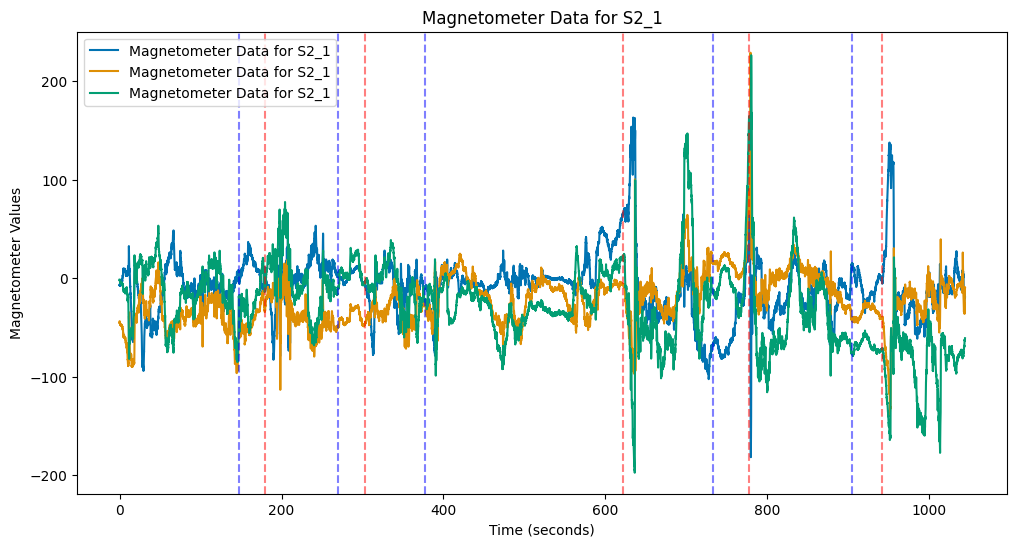

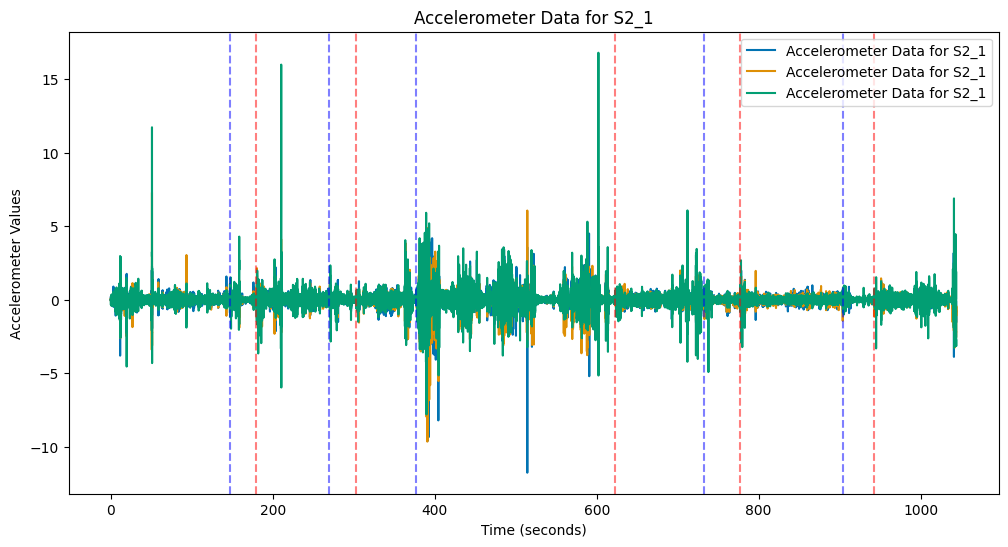

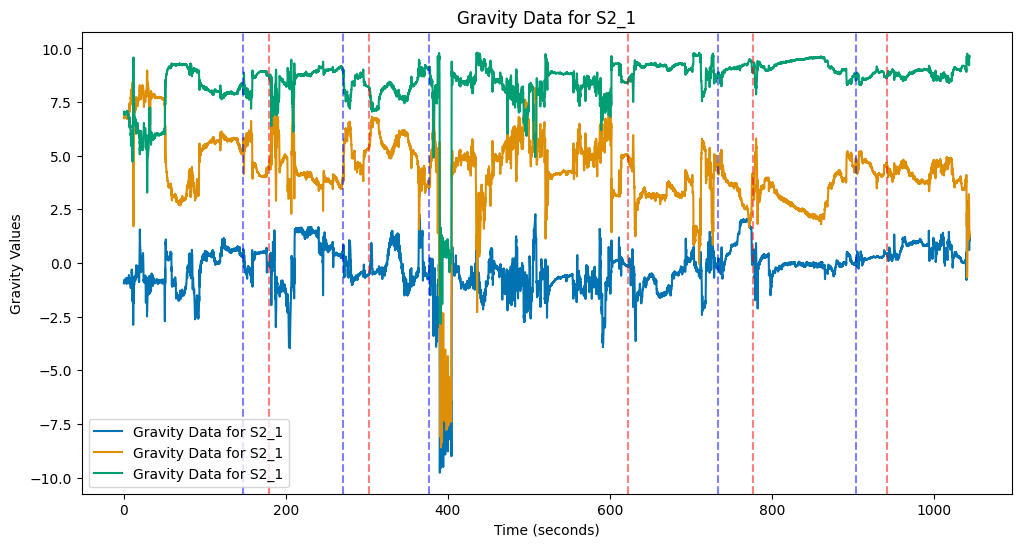

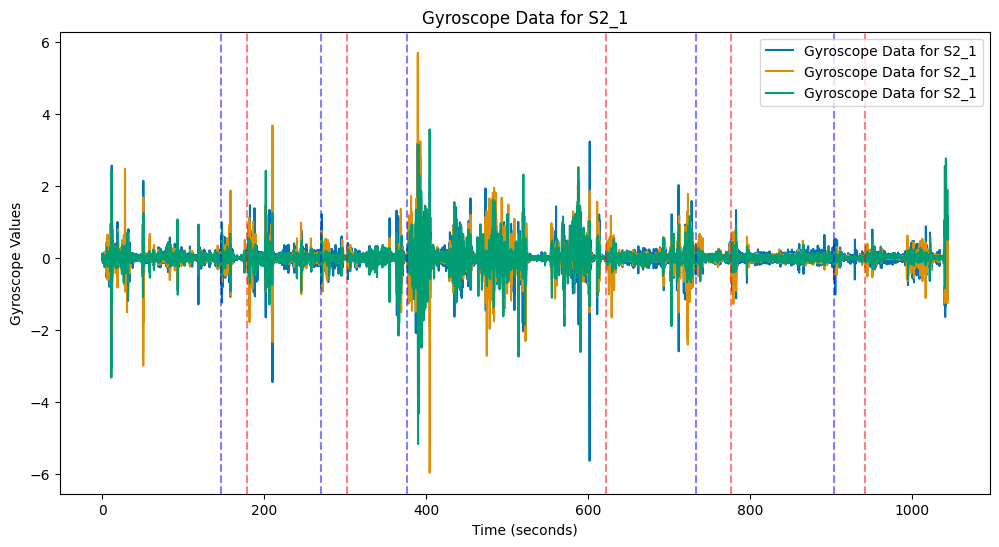

In [142]:
# Visualize time series data for S2_0 with sampling rate and intervals in seconds
import matplotlib.pyplot as plt

intervals = data_sample["intervals"]


# Define a function to plot data with sampling rate and intervals
def plot_with_sampling_rate(data, sampling_rate, title, ylabel):
    time = np.arange(len(data)) / sampling_rate  # Convert to seconds
    plt.figure(figsize=(12, 6))
    plt.plot(time, data, label=title)
    for start, end in intervals:
        plt.axvline(x=start, color="b", linestyle="--", alpha=0.5)
        plt.axvline(x=end, color="r", linestyle="--", alpha=0.5)
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()


# Plot each feature with its respective sampling rate
print(f"Data: {readme_sample}")
plot_with_sampling_rate(
    data_sample["magnetometer"][:, 1:],
    magnetometer_rate,
    f"Magnetometer Data for {train_str}_{train_index}",
    "Magnetometer Values",
)
plot_with_sampling_rate(
    data_sample["accelerometer"][:, 1:],
    accelerometer_rate,
    f"Accelerometer Data for {train_str}_{train_index}",
    "Accelerometer Values",
)
plot_with_sampling_rate(
    data_sample["gravity"][:, 1:],
    gravity_rate,
    f"Gravity Data for {train_str}_{train_index}",
    "Gravity Values",
)
plot_with_sampling_rate(
    data_sample["gyroscope"][:, 1:],
    gyroscope_rate,
    f"Gyroscope Data for {train_str}_{train_index}",
    "Gyroscope Values",
)

## Concat the data on a common time axis

In [143]:
import numpy as np, pandas as pd, pathlib, scipy.signal as sig


def to_df(data):
    sensors = ["magnetometer", "accelerometer", "gravity", "gyroscope"]
    columns = {
        "magnetometer": ["timestamp", "magne_x", "magne_y", "magne_z"],
        "accelerometer": ["timestamp", "accel_x", "accel_y", "accel_z"],
        "gravity": ["timestamp", "gravi_x", "gravi_y", "gravi_z"],
        "gyroscope": ["timestamp", "gyros_x", "gyros_y", "gyros_z"],
    }
    dfs = [
        pd.DataFrame(data[sensor], columns=columns[sensor])
        .assign(timestamp=lambda df: pd.to_datetime(df["timestamp"], unit="s"))
        .set_index("timestamp")
        for sensor in sensors
    ]
    df = pd.concat(dfs, axis=1)
    df.index = df.index - pd.Timestamp("1970-01-01") + pd.Timestamp("2024-01-01")
    return df


df = to_df(data_sample)
# Adjust the index to start from 2024-01-01

df.head(2)  # open this in DataWrangler to see the data

,magne_x,magne_y,magne_z,accel_x,accel_y,accel_z,gravi_x,gravi_y,gravi_z,gyros_x,gyros_y,gyros_z
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00.000000000,-6.73125,-44.981251,-1.44375,-0.00901,0.053899,0.04447,-0.945598,6.747225,7.053452,0.011072,0.038025,0.013133
2024-01-01 00:00:00.002381104,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.009239,0.039858,0.010690


# RESAMPLE AND INTERPOLATE!

In [144]:
# possible adjustments:
# use interpolation method="spline", order=3
df_uniform = df.copy()
df_uniform = df_uniform.resample("10ms").mean().interpolate()
display(df_uniform.head(2))
# print(df_uniform.shape)
df_uniform

,magne_x,magne_y,magne_z,accel_x,accel_y,accel_z,gravi_x,gravi_y,gravi_z,gyros_x,gyros_y,gyros_z
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00.000,-6.73125,-44.981251,-1.44375,-0.004676,0.034549,0.037859,-0.946684,6.747543,7.053002,0.009606,0.040346,0.009224
2024-01-01 00:00:00.010,-6.73125,-44.568752,-1.63125,0.008453,-0.027288,0.034599,-0.949744,6.748204,7.051958,0.014279,0.047493,0.006108


,magne_x,magne_y,magne_z,accel_x,accel_y,accel_z,gravi_x,gravi_y,gravi_z,gyros_x,gyros_y,gyros_z
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00.000,-6.731250,-44.981251,-1.443750,-0.004676,0.034549,0.037859,-0.946684,6.747543,7.053002,0.009606,0.040346,0.009224
2024-01-01 00:00:00.010,-6.731250,-44.568752,-1.631250,0.008453,-0.027288,0.034599,-0.949744,6.748204,7.051958,0.014279,0.047493,0.006108
2024-01-01 00:00:00.020,-6.956250,-44.362503,-1.631250,-0.001174,-0.046682,0.009357,-0.952675,6.749269,7.050543,0.024663,0.051311,0.007636
2024-01-01 00:00:00.030,-6.993750,-44.362503,-1.875000,-0.034144,-0.074359,0.004777,-0.955632,6.751039,7.048448,0.038102,0.049173,0.016035
2024-01-01 00:00:00.040,-6.600000,-44.231251,-1.781250,-0.060875,-0.071440,-0.012293,-0.958269,6.754034,7.045221,0.055053,0.050853,0.031306
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-01-01 00:17:23.950,-20.062500,-9.431251,-61.668751,-0.829399,-0.698201,-2.848560,1.050727,1.277384,9.666155,0.447751,-0.040087,0.769897
2024-01-01 00:17:23.960,-19.950001,-9.318750,-61.762501,-0.717393,-0.498380,-2.671497,1.082961,1.313447,9.657755,0.489900,-0.329934,0.746226
2024-01-01 00:17:23.970,-19.631250,-8.981251,-61.331253,-0.825585,-0.658439,-3.017603,1.131640,1.354491,9.646494,0.544112,-0.468291,0.677506


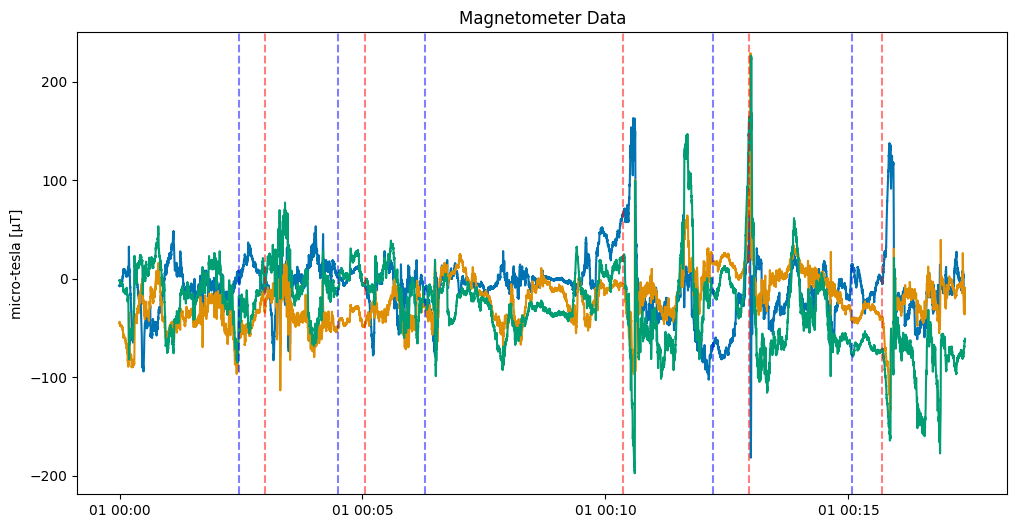

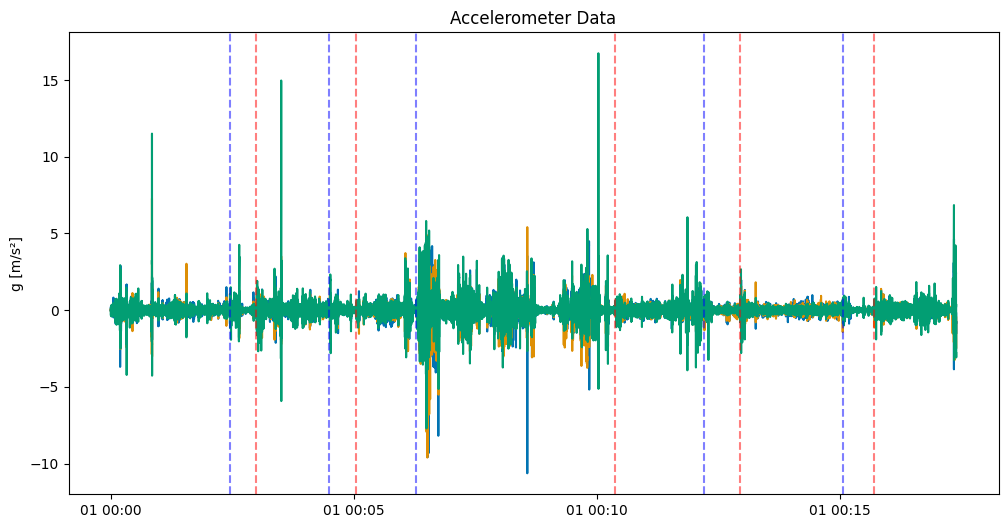

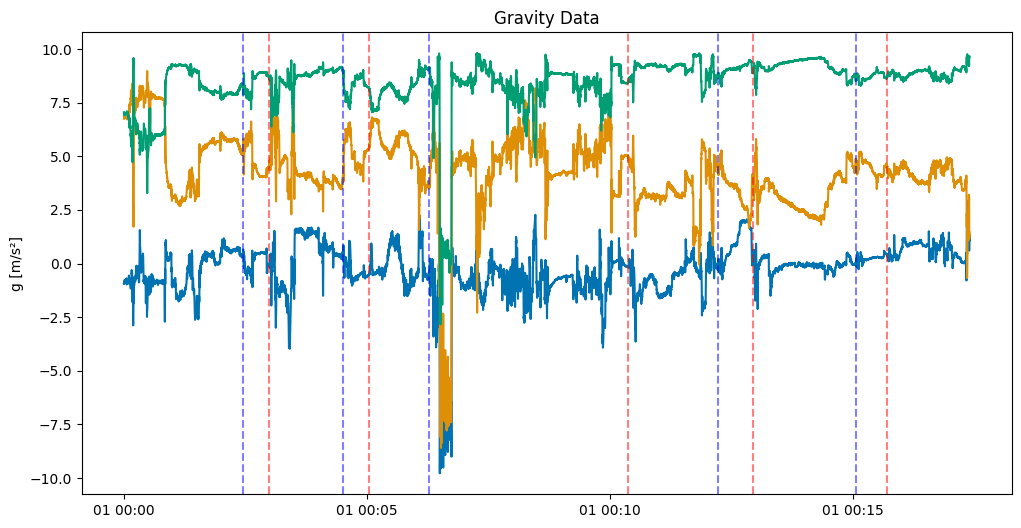

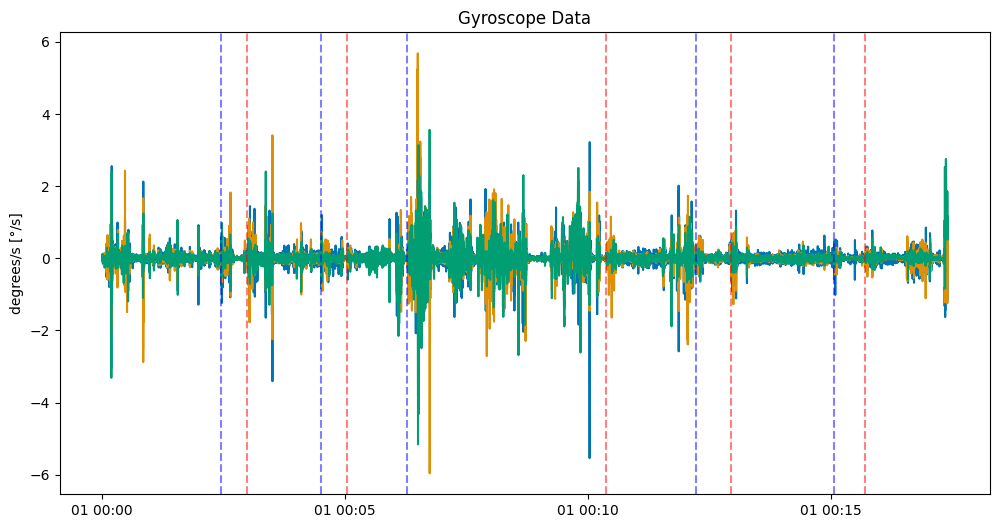

,magne_x,magne_y,magne_z,accel_x,accel_y,accel_z,gravi_x,gravi_y,gravi_z,gyros_x,gyros_y,gyros_z
timestamp,,,,,,,,,,,,
2024-01-01 00:00:00.000,-6.73125,-44.981251,-1.44375,-0.004676,0.034549,0.037859,-0.946684,6.747543,7.053002,0.009606,0.040346,0.009224
2024-01-01 00:00:00.010,-6.73125,-44.568752,-1.63125,0.008453,-0.027288,0.034599,-0.949744,6.748204,7.051958,0.014279,0.047493,0.006108
2024-01-01 00:00:00.020,-6.95625,-44.362503,-1.63125,-0.001174,-0.046682,0.009357,-0.952675,6.749269,7.050543,0.024663,0.051311,0.007636
2024-01-01 00:00:00.030,-6.99375,-44.362503,-1.87500,-0.034144,-0.074359,0.004777,-0.955632,6.751039,7.048448,0.038102,0.049173,0.016035
2024-01-01 00:00:00.040,-6.60000,-44.231251,-1.78125,-0.060875,-0.071440,-0.012293,-0.958269,6.754034,7.045221,0.055053,0.050853,0.031306


In [145]:
import seaborn as sns
# sns.color_palette("cubehelix", as_cmap=True)
# sns..color_palette("Spectral", as_cmap=True)
# sns.color_palette("Spectral", as_cmap=True)
sns.set_palette("colorblind")

plt.figure(figsize=(12, 6))
plt.title("Magnetometer Data")
plt.plot(df_uniform[["magne_x", "magne_y", "magne_z"]])
for start, end in intervals:
    start_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(start, unit="s")
    end_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(end, unit="s")
    plt.axvline(x=start_timestamp, color="b", linestyle="--", alpha=0.5)
    plt.axvline(x=end_timestamp, color="r", linestyle="--", alpha=0.5)
    plt.ylabel("micro-tesla [µT]")
plt.show()
# plot the other sensors
plt.figure(figsize=(12, 6))
plt.title("Accelerometer Data")
plt.plot(df_uniform[["accel_x", "accel_y", "accel_z"]])
for start, end in intervals:
    start_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(start, unit="s")
    end_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(end, unit="s")
    plt.axvline(x=start_timestamp, color="b", linestyle="--", alpha=0.5)
    plt.axvline(x=end_timestamp, color="r", linestyle="--", alpha=0.5)
plt.ylabel("g [m/s²]")
plt.show()
# plot the other sensors
plt.figure(figsize=(12, 6))
plt.title("Gravity Data")
plt.plot(df_uniform[["gravi_x", "gravi_y", "gravi_z"]])
for start, end in intervals:
    start_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(start, unit="s")
    end_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(end, unit="s")
    plt.axvline(x=start_timestamp, color="b", linestyle="--", alpha=0.5)
    plt.axvline(x=end_timestamp, color="r", linestyle="--", alpha=0.5)
plt.ylabel("g [m/s²]")
plt.show()
# plot the other sensors
plt.figure(figsize=(12, 6))
plt.title("Gyroscope Data")
plt.plot(df_uniform[["gyros_x", "gyros_y", "gyros_z"]])
for start, end in intervals:
    start_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(start, unit="s")
    end_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(end, unit="s")
    plt.axvline(x=start_timestamp, color="b", linestyle="--", alpha=0.5)
    plt.axvline(x=end_timestamp, color="r", linestyle="--", alpha=0.5)
plt.ylabel("degrees/s [°/s]")
plt.show()

df_uniform.head()

In [146]:
# Feature Engineering
acc = df_uniform[["accel_x", "accel_y", "accel_z"]].values
gra = df_uniform[["gravi_x", "gravi_y", "gravi_z"]].values
gyr = df_uniform[["gyros_x", "gyros_y", "gyros_z"]].values

df_uniform["dyn_acc"] = np.linalg.norm(acc - gra, axis=1)
df_uniform["gyro_mag"] = np.linalg.norm(gyr, axis=1)
df_uniform["mag_mag"] = np.linalg.norm(
    df_uniform[["magne_x", "magne_y", "magne_z"]].values, axis=1
)

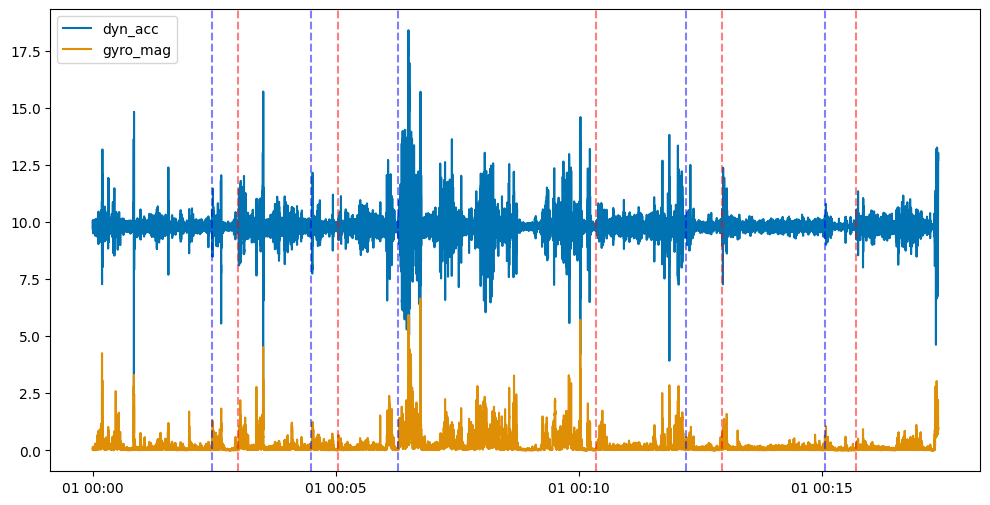

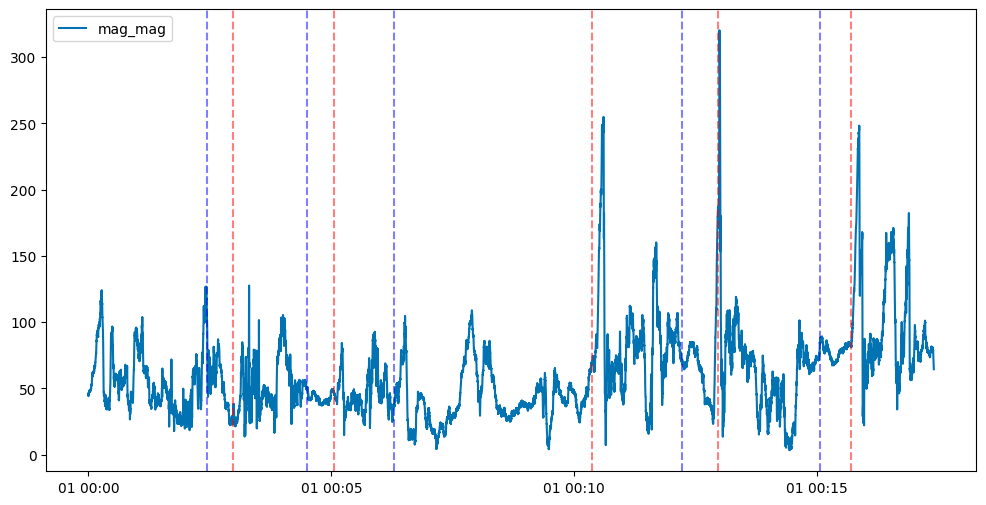

In [147]:
# plot the new features
plt.figure(figsize=(12, 6))
plt.plot(df_uniform[["dyn_acc", "gyro_mag"]])
for start, end in intervals:
    start_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(start, unit="s")
    end_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(end, unit="s")
    plt.axvline(x=start_timestamp, color="b", linestyle="--", alpha=0.5)
    plt.axvline(x=end_timestamp, color="r", linestyle="--", alpha=0.5)
plt.legend(["dyn_acc", "gyro_mag"])
plt.show()
plt.figure(figsize=(12, 6))
plt.plot(df_uniform[["mag_mag"]])
for start, end in intervals:
    start_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(start, unit="s")
    end_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(end, unit="s")
    plt.axvline(x=start_timestamp, color="b", linestyle="--", alpha=0.5)
    plt.axvline(x=end_timestamp, color="r", linestyle="--", alpha=0.5)
plt.legend(["mag_mag"])
plt.show()

In [148]:
# win = "1s"  # pandas offset alias: 1‑second

agg = {
    "dyn_acc": ["mean", "std", "max", "median"],
    "gyro_mag": ["mean", "std", "max"],
    "mag_mag": ["std"],  # variance in magnetic field ↑ when doors open
}

# agg = {
#     "dyn_acc": ["mean", "std", "max", "median"],
#     "gyro_mag": ["mean", "std", "max", "median"],
#     "mag_mag": ["mean", "std", "max", "median"],  # variance in magnetic field ↑ when doors open
# }

df_feat = df_uniform.resample("1s").agg(agg)

df_feat.columns = ["_".join(c) for c in df_feat.columns]  # flatten index
base_cols = df_feat.columns.tolist()
print(base_cols)

# ADD LAG FEATURES
lag_steps = [1, 2]
for l in lag_steps:
    df_feat[[f"{c}_lag{l}" for c in base_cols]] = df_feat[base_cols].shift(l)


# first‑order differences (current – previous second)
df_feat[[f"{c}_diff1" for c in base_cols]] = df_feat[base_cols] - df_feat[
    base_cols
].shift(1)

df_feat = df_feat.dropna()

['dyn_acc_mean', 'dyn_acc_std', 'dyn_acc_max', 'dyn_acc_median', 'gyro_mag_mean', 'gyro_mag_std', 'gyro_mag_max', 'mag_mag_std']


In [149]:
print(df_feat.columns)

Index(['dyn_acc_mean', 'dyn_acc_std', 'dyn_acc_max', 'dyn_acc_median',
       'gyro_mag_mean', 'gyro_mag_std', 'gyro_mag_max', 'mag_mag_std',
       'dyn_acc_mean_lag1', 'dyn_acc_std_lag1', 'dyn_acc_max_lag1',
       'dyn_acc_median_lag1', 'gyro_mag_mean_lag1', 'gyro_mag_std_lag1',
       'gyro_mag_max_lag1', 'mag_mag_std_lag1', 'dyn_acc_mean_lag2',
       'dyn_acc_std_lag2', 'dyn_acc_max_lag2', 'dyn_acc_median_lag2',
       'gyro_mag_mean_lag2', 'gyro_mag_std_lag2', 'gyro_mag_max_lag2',
       'mag_mag_std_lag2', 'dyn_acc_mean_diff1', 'dyn_acc_std_diff1',
       'dyn_acc_max_diff1', 'dyn_acc_median_diff1', 'gyro_mag_mean_diff1',
       'gyro_mag_std_diff1', 'gyro_mag_max_diff1', 'mag_mag_std_diff1'],
      dtype='object')


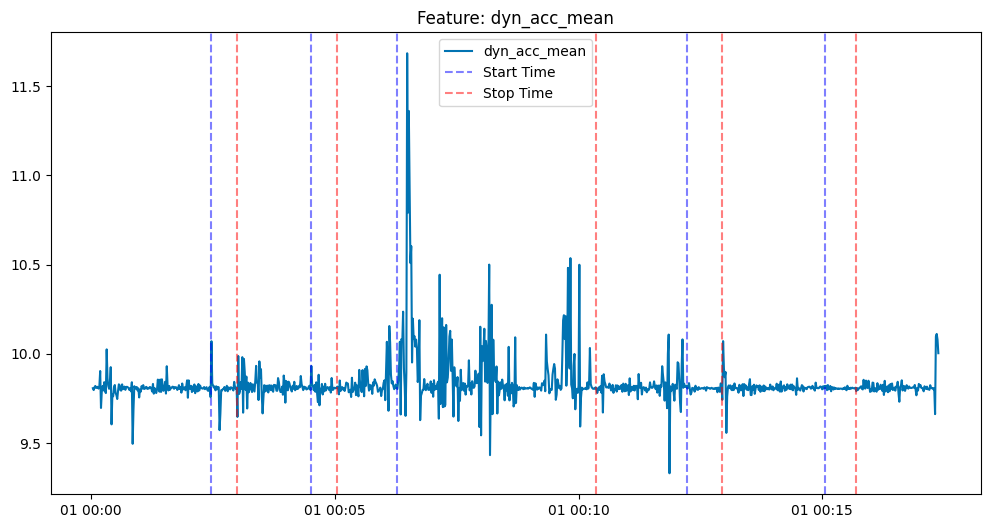

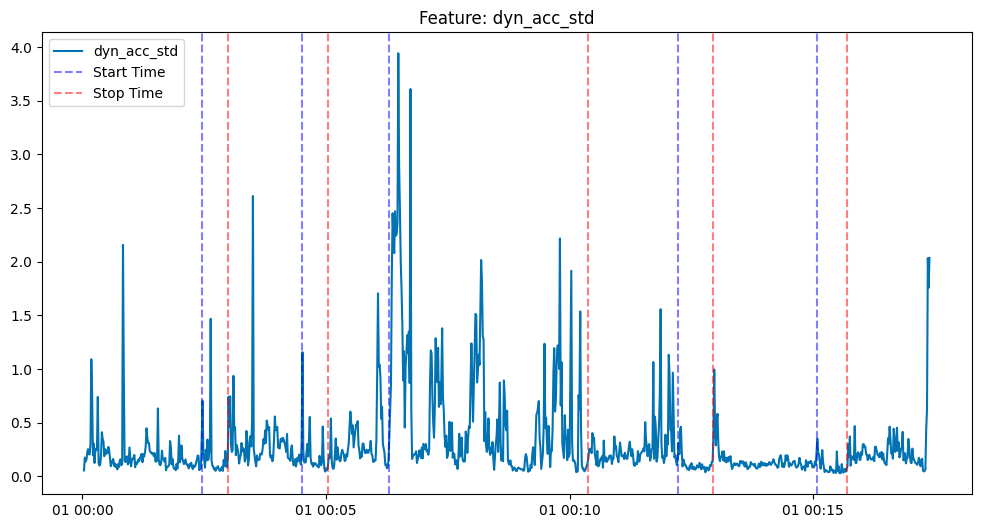

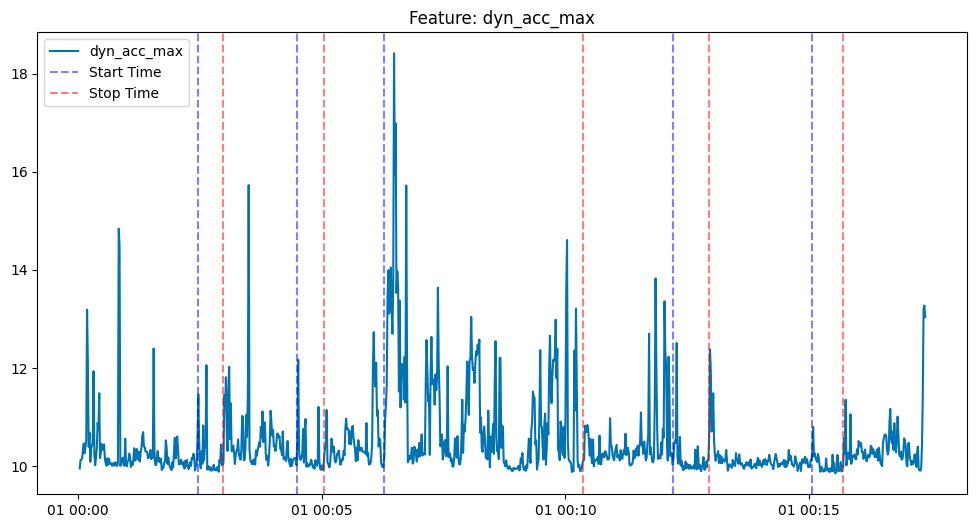

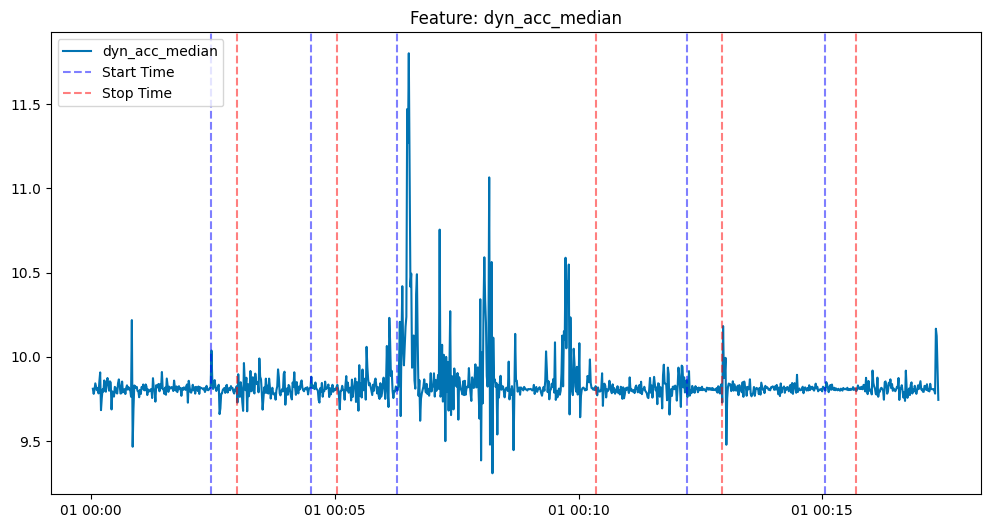

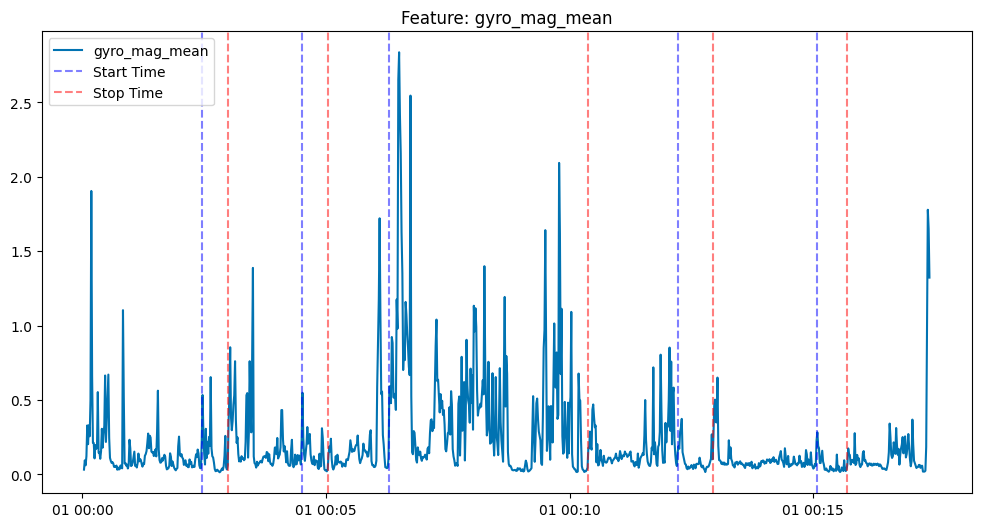

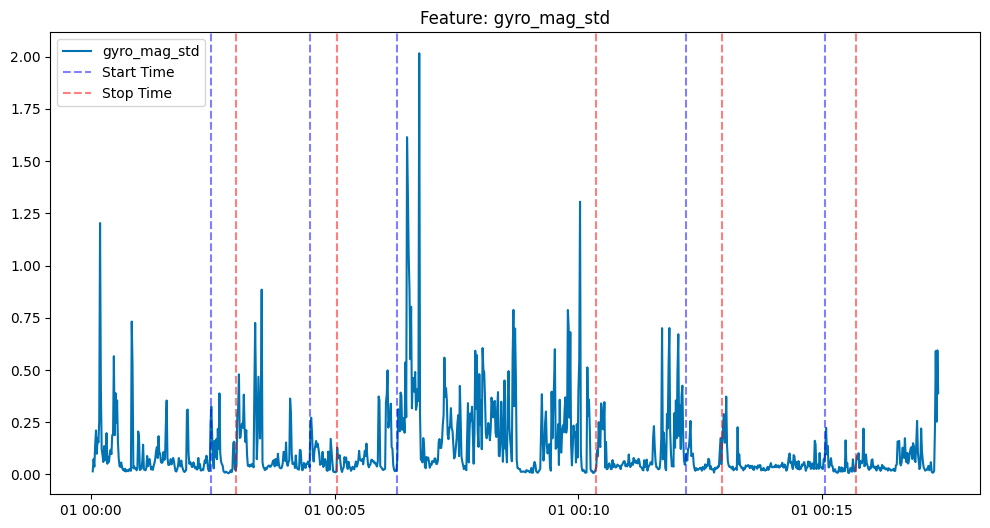

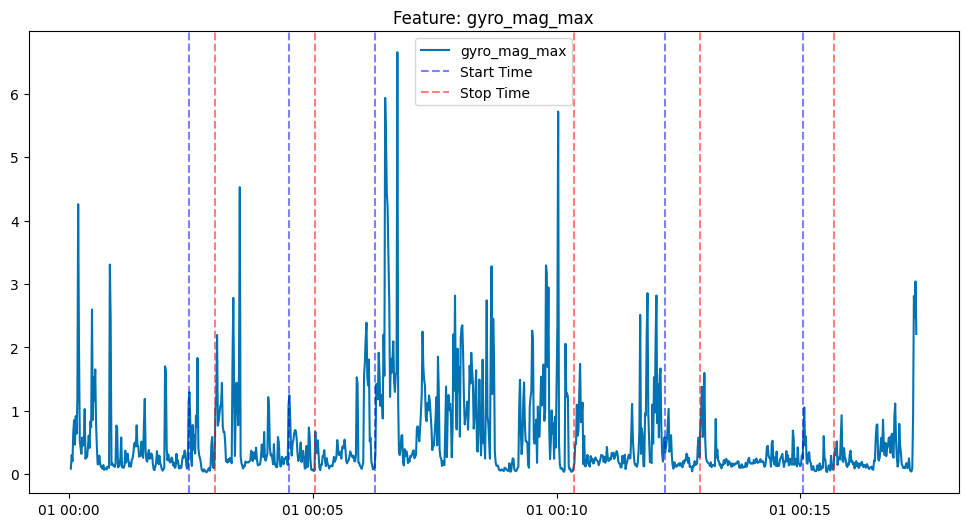

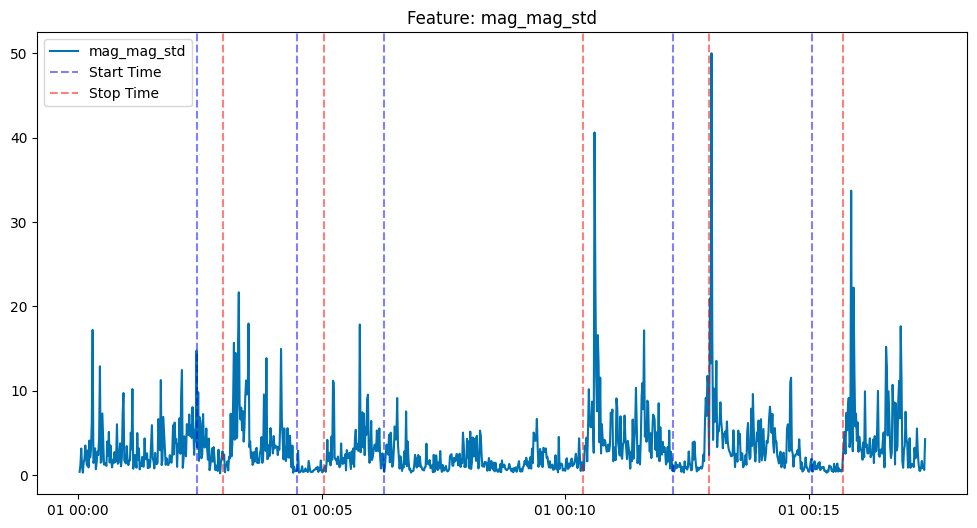

In [150]:
# plot the new features

for col in df_feat.columns:
    if "_lag" in col:
        continue
    if "_diff" in col:
        continue
    plt.figure(figsize=(12, 6))
    plt.plot(df_feat.index, df_feat[col], label=col)
    for start, end in intervals:
        start_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(start, unit="s")
        end_timestamp = pd.Timestamp("2024-01-01") + pd.to_timedelta(end, unit="s")
        plt.axvline(
            x=start_timestamp,
            color="b",
            linestyle="--",
            alpha=0.5,
            label=(
                "Start Time"
                if "Start Time" not in plt.gca().get_legend_handles_labels()[1]
                else ""
            ),
        )
        plt.axvline(
            x=end_timestamp,
            color="r",
            linestyle="--",
            alpha=0.5,
            label=(
                "Stop Time"
                if "Stop Time" not in plt.gca().get_legend_handles_labels()[1]
                else ""
            ),
        )
    plt.legend()
    plt.title(f"Feature: {col}")
    plt.show()

It looks like mag_mag_std is showing some clear indications, if the train is not moving 

### Prepraring ground truth data


In [151]:
# ground‑truth intervals in *seconds since trip start*
gt = data_sample["intervals"]  # list[(start, end)]

y = np.zeros(len(df_feat), dtype=int)
t_centres = (df_feat.index - df_feat.index[0]).total_seconds()

for start, end in gt:
    y[(t_centres >= start) & (t_centres <= end)] = 1
print(y.mean())

0.3752399232245681


In [152]:
df_feat.shape

(1042, 32)

In [153]:
from processing.quantile_clipper import QuantileClipper

In [154]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score


ratio = 0.7
split_idx = int(len(df_feat) * ratio)
print(f"Split index: {split_idx}")

X_train = df_feat.iloc[:split_idx]
X_val = df_feat.iloc[split_idx:]
y_train = y[:split_idx]
y_val = y[split_idx:]

print("X_train shape, y_train shape", X_train.shape, y_train.shape)
print("X_val shape, y_val shape    ", X_val.shape, y_val.shape)


pipe = Pipeline(
    [
        ("clip", QuantileClipper(q_lower=1, q_upper=99)),
        (
            "hgbt",
            HistGradientBoostingClassifier(
                max_depth=3,
                learning_rate=0.12,
                class_weight="balanced",
                random_state=42,
            ),
        ),
    ]
)

pipe.fit(X_train, y_train)

predictions_validation = pipe.predict(X_val)
print(f"val-F1 = {f1_score(y_val, predictions_validation):.3f}")
print(
    f"Sum Predictions: {predictions_validation.sum()}, Sum Ground Truth: {y_val.sum()}"
)

Split index: 729
X_train shape, y_train shape (729, 32) (729,)
X_val shape, y_val shape     (313, 32) (313,)
val-F1 = 0.735
Sum Predictions: 85, Sum Ground Truth: 81


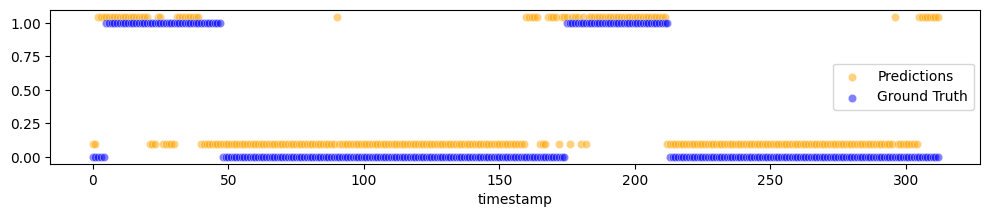

In [155]:
plt.figure(figsize=(12, 2))
sns.scatterplot(
    x=(X_val.index - X_val.index[0]).total_seconds(),
    y=(predictions_validation + 0.1) * 0.95,  # have them below the ground truth
    label="Predictions",
    color="orange",
    alpha=0.5,
)
sns.scatterplot(
    x=(X_val.index - X_val.index[0]).total_seconds(),
    y=y_val,
    label="Ground Truth",
    color="blue",
    alpha=0.5,
)
plt.show()

In [156]:
import numpy as np
from scipy.signal import medfilt  # median filter


def proba_to_intervals(
    proba,  # 1‑D array, same length as time_index
    time_index,  # X_val.index  (DateTimeIndex)
    recording_start,  # df_feat.index[0]  (Timestamp)
    thr=0.60,
    win_len=1.0,  # seconds
    min_stop=1.0,
    merge_gap=15.0,
    med_k=7,
    return_datetime=False,
):  # if True, also return Timestamp pairs
    """
    Convert window‑level probabilities to stop intervals.

    Returns
    -------
    list[(start_s, end_s)]                      if return_datetime == False
    list[(start_s, end_s, start_dt, end_dt)]    if return_datetime == True
        where *_s  are seconds since `recording_start`
              *_dt are pandas.Timestamp
    """
    # ------------------------------------------------------------------
    # 0.  seconds since the *trip start*
    # ------------------------------------------------------------------
    t_c_abs = (time_index - recording_start).total_seconds().values
    file_len = t_c_abs[-1] + win_len / 2  # clip right edge
    print("file_len", file_len)

    # ------------------------------------------------------------------
    # 1.  binary mask (+ median smoothing)
    # ------------------------------------------------------------------
    mask = (proba >= thr).astype(int)
    if med_k > 1:
        mask = medfilt(mask, kernel_size=med_k)

    # ------------------------------------------------------------------
    # 2.  locate start / end indices where mask flips
    # ------------------------------------------------------------------
    edges = np.diff(mask, prepend=0, append=0)
    start_idx = np.flatnonzero(edges == 1)
    end_idx = np.flatnonzero(edges == -1)

    # ------------------------------------------------------------------
    # 3.  build raw intervals, clip to [0, file_len], drop short ones
    # ------------------------------------------------------------------
    intervals = []
    for s_i, e_i in zip(start_idx, end_idx):
        t0 = max(0.0, t_c_abs[s_i] - win_len / 2)
        t1 = min(file_len, t_c_abs[e_i - 1] + win_len / 2)
        if t1 - t0 >= min_stop:
            intervals.append([t0, t1])

    # ------------------------------------------------------------------
    # 4.  merge gaps shorter than merge_gap
    # ------------------------------------------------------------------
    merged = []
    for s, e in intervals:
        if not merged:
            merged.append([s, e])
        elif s - merged[-1][1] <= merge_gap:
            merged[-1][1] = e
        else:
            merged.append([s, e])

    if not return_datetime:
        return [tuple(ix) for ix in merged]

    # also return the wall‑clock times
    merged_dt = [
        (
            s,
            e,
            recording_start + pd.Timedelta(seconds=s),
            recording_start + pd.Timedelta(seconds=e),
        )
        for s, e in merged
    ]
    return merged_dt

In [157]:
# 1. probabilities for exactly the windows in X_val
proba_val = pipe.predict_proba(X_val)[:, 1]

# 2. pass the *global* trip start (first index of df_feat)
recording_start = df_feat.index[0]  # pandas.Timestamp

pred_int = proba_to_intervals(
    proba_val,
    X_val.index,
    recording_start,
    thr=0.70,
    win_len=1.0,
    min_stop=10.0,
    merge_gap=3.0,
    return_datetime=True,
)  # to get both numeric & datetime

for s, e, s_dt, e_dt in pred_int:
    print(f"{s:6.1f}s – {e:6.1f}s   |   {s_dt.time()} → {e_dt.time()}")

print("*" * 10, "GROUND TRUTH", "*" * 10)
for s, e in intervals:
    print(f"{s:6.1f}s – {e:6.1f}s   |   ")

file_len 1041.5
 731.5s –  751.5s   |   00:12:13.500000 → 00:12:33.500000
 911.5s –  940.5s   |   00:15:13.500000 → 00:15:42.500000
********** GROUND TRUTH **********
 147.0s –  179.0s   |   
 270.0s –  303.0s   |   
 377.0s –  622.0s   |   
 733.0s –  777.0s   |   
 904.0s –  942.0s   |   


---

# USE ALL THE DATA

In [158]:
# ---------------------------------------------------------------------
#  helper: convert ONE data.npz into       X_feat (DataFrame),
#                                          y      (1‑D array),
#                                          group  (string id)
# ---------------------------------------------------------------------
def trip_to_features(npz, group_id):  # data_sample from np.load(...)  # e.g. "S2_01"
    # ---------- concat on native timestamps, resample to 20 Hz ----------
    df_raw = to_df(npz)
    df_raw.index = (
        df_raw.index - pd.Timestamp("1970-01-01") + pd.Timestamp("2024-01-01")
    )
    df = df_raw.resample("10ms").mean().interpolate()  # 20 Hz

    # ---------- per‑sample magnitudes ----------
    acc = df[["accel_x", "accel_y", "accel_z"]].values
    gra = df[["gravi_x", "gravi_y", "gravi_z"]].values
    gyr = df[["gyros_x", "gyros_y", "gyros_z"]].values

    df["dyn_acc"] = np.linalg.norm(acc - gra, axis=1)
    df["gyro_mag"] = np.linalg.norm(gyr, axis=1)
    df["mag_mag"] = np.linalg.norm(df[["magne_x", "magne_y", "magne_z"]].values, axis=1)

    # ---------- 1‑second windows ----------
    win = "1s"
    agg = {
        "dyn_acc": ["mean", "std", "max", "median"],
        "gyro_mag": ["mean", "std", "max"],
        "mag_mag": ["std"],
    }
    feat = df.resample(win).agg(agg)
    feat.columns = ["_".join(c) for c in feat.columns]
    base_cols = feat.columns.tolist()

    # lag features
    lag_steps = [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        13,
        14,
        15,
    ]
    lagged_features = {
        f"{c}_lag{l}": feat[c].shift(l) for l in lag_steps for c in base_cols
    }
    feat = pd.concat([feat, pd.DataFrame(lagged_features, index=feat.index)], axis=1)

    feat = feat.dropna()

    # ---------- labels ----------
    y = np.zeros(len(feat), dtype=int)
    t_centres = (feat.index - feat.index[0]).total_seconds()
    for s, e in npz["intervals"]:
        y[(t_centres >= s) & (t_centres <= e)] = 1

    return feat, y, np.repeat(group_id, len(feat))

In [159]:
X_list, y_list, g_list = [], [], []

for train_name, trips in train_data.items():  # your dict from load_train_data
    for idx, trip in enumerate(trips):
        group_id = f"{train_name}_{idx}"  # e.g. "S2_03"
        Xf, yf, gf = trip_to_features(trip["data"], group_id)
        X_list.append(Xf)
        y_list.append(yf)
        g_list.append(gf)

X_all = pd.concat(X_list, axis=0)
y_all = np.concatenate(y_list)
groups = np.concatenate(g_list)
print(X_all.shape, y_all.shape, groups.shape)

# the data size does not change, because we make our features to 1 second windows
display(X_all.head(2))

(39249, 128) (39249,) (39249,)


,dyn_acc_mean,dyn_acc_std,dyn_acc_max,dyn_acc_median,gyro_mag_mean,gyro_mag_std,gyro_mag_max,mag_mag_std,dyn_acc_mean_lag1,dyn_acc_std_lag1,...,gyro_mag_max_lag14,mag_mag_std_lag14,dyn_acc_mean_lag15,dyn_acc_std_lag15,dyn_acc_max_lag15,dyn_acc_median_lag15,gyro_mag_mean_lag15,gyro_mag_std_lag15,gyro_mag_max_lag15,mag_mag_std_lag15
timestamp,,,,,,,,,,,,,,,,,,,,,
2077-12-31 00:00:15,9.809768,0.039210,9.906414,9.811867,0.010168,0.005073,0.026596,11.496141,9.807511,0.049293,...,0.301354,0.359967,9.841879,0.173257,10.201707,9.845593,0.141266,0.072007,0.299288,0.724380
2077-12-31 00:00:16,9.812677,0.041828,9.928501,9.814340,0.012960,0.008079,0.039332,11.864180,9.809768,0.039210,...,0.199928,0.537744,9.873269,0.229462,10.412476,9.877652,0.173861,0.055684,0.301354,0.359967


(30633,) (8616,)
train_idx: [0 1 2 3 4] ...
val_idx:   [5381 5382 5383 5384 5385] ...
val‑F1 = 0.848


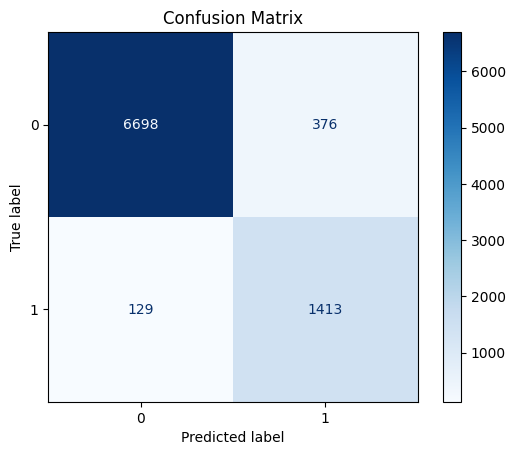

In [160]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score

gss = GroupShuffleSplit(test_size=0.2, random_state=4)  # 25 % of trips for val
train_idx, val_idx = next(gss.split(X_all, y_all, groups))
print(train_idx.shape, val_idx.shape)
print(f"train_idx: {train_idx[:5]} ...")
print(f"val_idx:   {val_idx[:5]} ...")

X_train, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
y_train, y_val = y_all[train_idx], y_all[val_idx]

pipe = Pipeline(
    [
        ("clip", QuantileClipper(q_lower=1, q_upper=99)),
        (
            "clf",
            HistGradientBoostingClassifier(
                max_depth=10,
                learning_rate=0.12,
                class_weight="balanced",
                early_stopping=True,
                random_state=42,
            ),
        ),
    ]
)

pipe.fit(X_train, y_train)
print(f"val‑F1 = {f1_score(y_val, pipe.predict(X_val)):.3f}")
# confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_val, pipe.predict(X_val))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipe.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

- 1 lag --> val-f1 0.725
- 2 lag --> val-f1 0.76
- 5 lag --> val-f1 0.796
- 10 lag --> val-f1 0.826
- 15 lag --> val-f1 0.845
- 20 lag --> val-f1 0.847

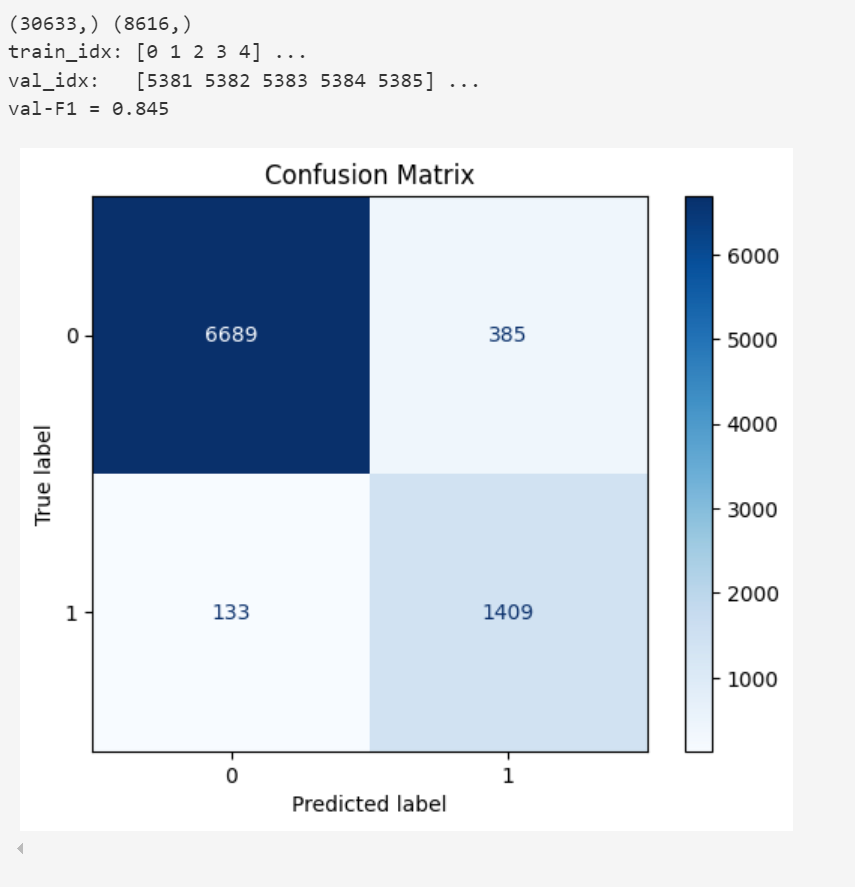

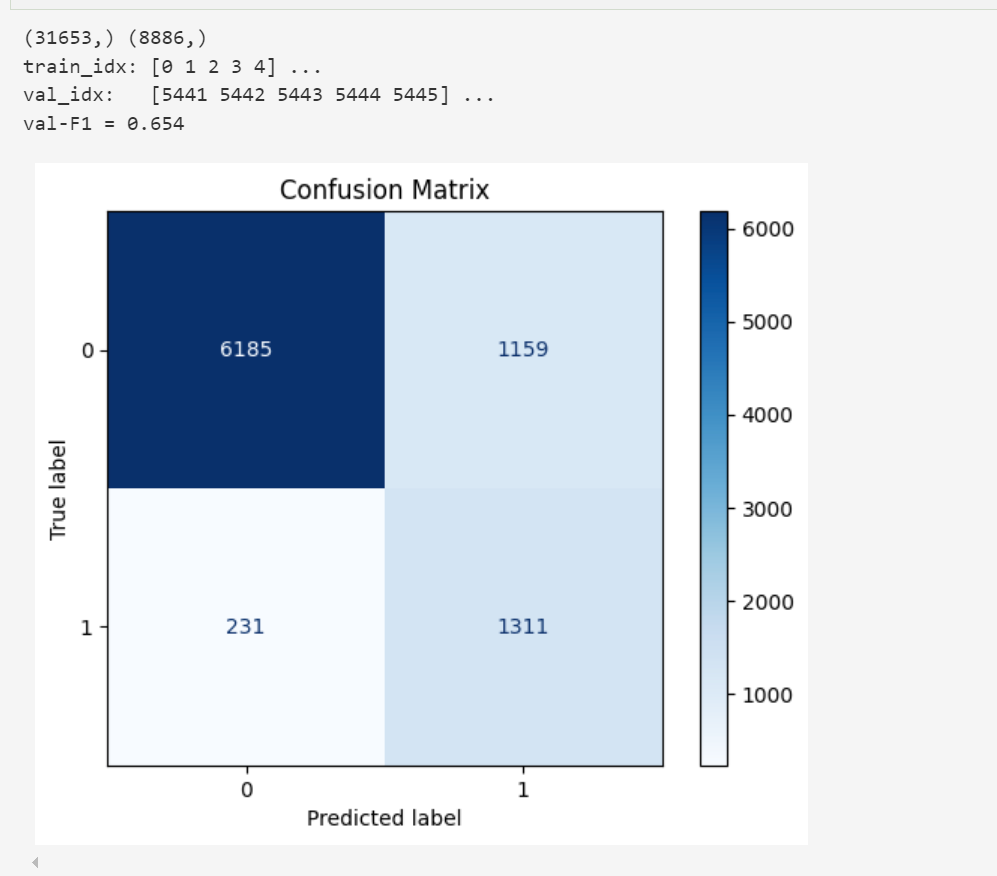

In [161]:
def save_model(model_name, model_dir, model):
    import joblib
    import os

    os.makedirs(model_dir, exist_ok=True)
    models = [f for f in os.listdir(model_dir) if f.endswith(".joblib")]
    if models:
        latest_model = max(models, key=lambda x: int(x.split("_")[-1].split(".")[0]))
        latest_index = int(latest_model.split("_")[-1].split(".")[0])
        new_index = latest_index + 1
    else:
        new_index = 1
    model_path = os.path.join("saved_models", f"{model_name}_{new_index}.joblib")
    joblib.dump(pipe, model_path)
    print("Model saved to", model_path)
    return model_path

In [162]:
import joblib

model_path_save = save_model("train_stop_detector", "saved_models", pipe)

pipe = joblib.load(model_path_save)  # load
pipe

ValueError: invalid literal for int() with base 10: 'postproc'

In [ ]:
for group in np.unique(groups[val_idx]):
    mask = groups[val_idx] == group
    X_trip = X_all.iloc[val_idx[mask]]
    proba = pipe.predict_proba(X_trip)[:, 1]

    recording_start = X_trip.index[0]
    pred_int = proba_to_intervals(
        proba,
        X_trip.index,
        recording_start,
        thr=0.65,
        win_len=1.0,
        min_stop=10.0,
        merge_gap=3.0,
    )

    print(group, pred_int)

file_len 1630.5
S25_4 [(np.float64(132.5), np.float64(163.5)), (np.float64(268.5), np.float64(300.5)), (np.float64(522.5), np.float64(674.5)), (np.float64(827.5), np.float64(848.5)), (np.float64(921.5), np.float64(941.5)), (np.float64(1041.5), np.float64(1069.5)), (np.float64(1130.5), np.float64(1144.5)), (np.float64(1235.5), np.float64(1255.5)), (np.float64(1330.5), np.float64(1353.5)), (np.float64(1437.5), np.float64(1466.5)), (np.float64(1544.5), np.float64(1569.5))]
file_len 1529.5
S25_5 [(np.float64(110.5), np.float64(123.5)), (np.float64(213.5), np.float64(254.5)), (np.float64(337.5), np.float64(370.5)), (np.float64(524.5), np.float64(550.5)), (np.float64(766.5), np.float64(798.5)), (np.float64(951.5), np.float64(984.5)), (np.float64(1220.5), np.float64(1249.5)), (np.float64(1358.5), np.float64(1381.5)), (np.float64(1519.5), np.float64(1529.5))]
file_len 256.5
S3_12 [(np.float64(135.5), np.float64(164.5))]
file_len 252.5
S3_17 [(np.float64(100.5), np.float64(118.5))]
file_len 260

# Train Model on all data

In [ ]:
X_list, y_list, g_list = [], [], []

for train_name, trips in train_data.items():  # 83 folders
    for idx, trip in enumerate(trips):
        group_id = f"{train_name}_{idx}"
        Xf, yf, gf = trip_to_features(trip["data"], group_id)
        X_list.append(Xf)
        y_list.append(yf)
        g_list.append(gf)

X_all = pd.concat(X_list, axis=0)  # keep DatetimeIndex
y_all = np.concatenate(y_list)
groups = np.concatenate(g_list)
print(X_all.shape, y_all.mean())  # sanity‑check class ratio

(39249, 128) 0.18787739815027135


In [ ]:
pipe_final = Pipeline(
    [
        ("clip", QuantileClipper(q_lower=1, q_upper=99)),
        (
            "clf",
            HistGradientBoostingClassifier(
                max_depth=3,
                learning_rate=0.12,
                class_weight="balanced",
                early_stopping=True,
                random_state=42,
            ),
        ),
    ]
)

pipe_final.fit(X_all, y_all)

Pipeline(steps=[('clip', QuantileClipper(q_lower=1, q_upper=99)),
                ('clf',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                early_stopping=True,
                                                learning_rate=0.12, max_depth=3,
                                                random_state=42))])

In [ ]:
save_model("train_stop_detector", "saved_models", pipe_final)

Model saved to saved_models/train_stop_detector_14.joblib


'saved_models/train_stop_detector_14.joblib'